# Quantum Kernel Family Benchmark

Focus on quantum kernel classifiers, trainable quantum kernels, and classical kernel-style baselines. This notebook reports accuracy, runtime, paired deltas, and trainable-kernel alignment when available.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
from qml.benchmarks import compare_classification_models
from qml.reporting import print_table
import matplotlib.pyplot as plt

In [3]:
CONFIG = {
    "datasets": ["moons", "circles"],
    "seeds": [0],
    "n_samples": 32,
    "noise": 0.1,
    "test_size": 0.25,
}

kernel_models = [
    "quantum_kernel",
    "trainable_quantum_kernel",
    "svm_classifier",
    "knn_classifier",
]

model_kwargs = {
    "trainable_quantum_kernel": {"steps": 2, "embedding_layers": 1, "step_size": 0.08},
    "svm_classifier": {"kernel": "rbf", "c": 1.0, "gamma": "scale"},
}

In [4]:
def kernel_rows(dataset, result):
    rows = []
    for model, stats in result["summary"].items():
        row = {
            "dataset": dataset,
            "model": model,
            "test_accuracy": stats["test_accuracy"]["mean"],
            "ci95_low": stats["test_accuracy"]["ci95_low"],
            "ci95_high": stats["test_accuracy"]["ci95_high"],
            "gap": stats["generalization_gap"]["mean"],
            "runtime_s": stats["runtime_seconds"]["mean"],
        }
        if "final_alignment" in stats:
            row["alignment"] = stats["final_alignment"]["mean"]
        rows.append(row)
    return sorted(rows, key=lambda row: row["test_accuracy"], reverse=True)


def paired_rows(dataset, result):
    comparison = result["paired_vs_best_classical"]
    return [
        {
            "dataset": dataset,
            "reference": comparison["reference_model"],
            "model": model,
            "mean_delta": stats["mean_delta"]["mean"],
            "wins": stats["wins"],
            "losses": stats["losses"],
            "pairs": stats["n_pairs"],
        }
        for model, stats in comparison["comparisons"].items()
    ]

In [5]:
summary = []
paired = []
results_by_dataset = {}

for dataset in CONFIG["datasets"]:
    result = compare_classification_models(
        models=kernel_models,
        seeds=CONFIG["seeds"],
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["noise"],
        test_size=CONFIG["test_size"],
        dataset=dataset,
        model_kwargs=model_kwargs,
        save=False,
    )
    results_by_dataset[dataset] = result
    summary.extend(kernel_rows(dataset, result))
    paired.extend(paired_rows(dataset, result))

print_table(summary, title="Kernel-family benchmark summary")
print_table(paired, title="Paired deltas vs best classical kernel-style baseline")

Kernel-family benchmark summary
+---------+--------------------------+---------------+----------+-----------+----------+------------+
| dataset | model                    | test_accuracy | ci95_low | ci95_high | gap      | runtime_s  |
+---------+--------------------------+---------------+----------+-----------+----------+------------+
| moons   | quantum_kernel           | 0.75          | 0.75     | 0.75      | 0.166667 | 0.863331   |
| moons   | trainable_quantum_kernel | 0.75          | 0.75     | 0.75      | 0.166667 | 51.9044    |
| moons   | svm_classifier           | 0.75          | 0.75     | 0.75      | 0.166667 | 0.00341541 |
| moons   | knn_classifier           | 0.75          | 0.75     | 0.75      | 0.208333 | 0.00571792 |
| circles | quantum_kernel           | 0.875         | 0.875    | 0.875     | 0.125    | 0.831367   |
| circles | trainable_quantum_kernel | 0.875         | 0.875    | 0.875     | 0.125    | 51.4472    |
| circles | svm_classifier           | 0.875      

## Kernel-Family Plots

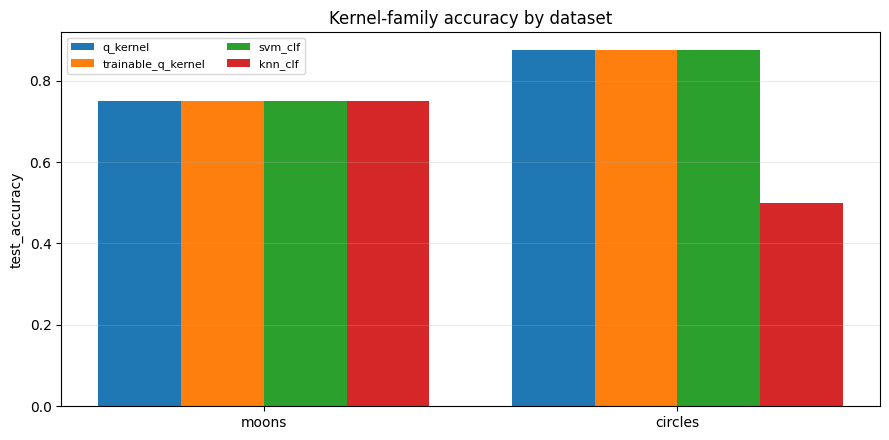

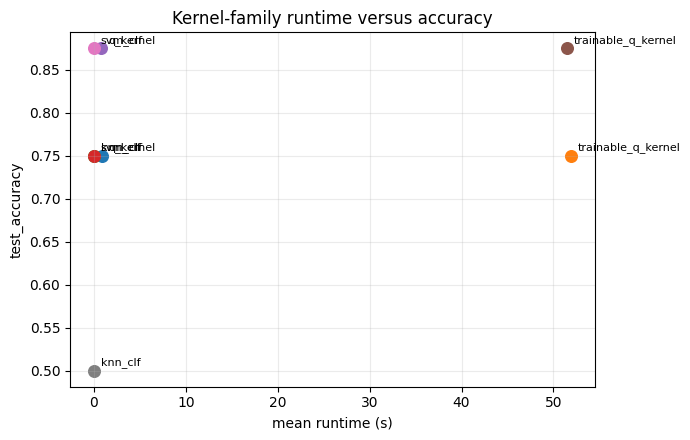

In [6]:

import matplotlib.pyplot as plt


def _short_label(label):
    return label.replace("quantum_", "q_").replace("_regression", "_reg").replace("_classifier", "_clf")


def plot_metric_bars(rows, metric, title, *, lower_is_better=False):
    ordered = sorted(rows, key=lambda row: row[metric], reverse=not lower_is_better)
    labels = [_short_label(row["model"]) for row in ordered]
    values = [row[metric] for row in ordered]
    errors = [
        [max(0.0, row[metric] - row.get("ci95_low", row[metric])) for row in ordered],
        [max(0.0, row.get("ci95_high", row[metric]) - row[metric]) for row in ordered],
    ]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(labels, values, yerr=errors, capsize=4, color="#3b82f6", edgecolor="#1f2937", linewidth=0.7)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_runtime_scatter(rows, metric, title, *, lower_is_better=False):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for row in rows:
        ax.scatter(row["runtime_s"], row[metric], s=70)
        ax.annotate(_short_label(row["model"]), (row["runtime_s"], row[metric]), xytext=(5, 4), textcoords="offset points", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("mean runtime (s)")
    ax.set_ylabel(metric)
    if lower_is_better:
        ax.invert_yaxis()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_dataset_bars(rows, metric, title, *, lower_is_better=False):
    datasets = list(dict.fromkeys(row["dataset"] for row in rows))
    models = list(dict.fromkeys(row["model"] for row in rows))
    width = 0.8 / max(1, len(models))
    x = list(range(len(datasets)))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for index, model in enumerate(models):
        values = []
        for dataset in datasets:
            match = next((row for row in rows if row["dataset"] == dataset and row["model"] == model), None)
            values.append(float("nan") if match is None else match[metric])
        offsets = [position - 0.4 + width / 2 + index * width for position in x]
        ax.bar(offsets, values, width=width, label=_short_label(model))
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xticks(x, datasets)
    if lower_is_better:
        ax.invert_yaxis()
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8, ncols=2)
    fig.tight_layout()
    plt.show()

plot_dataset_bars(summary, "test_accuracy", "Kernel-family accuracy by dataset")
plot_runtime_scatter(summary, "test_accuracy", "Kernel-family runtime versus accuracy")

## Diagnostic Checks

In [7]:
for dataset, result in results_by_dataset.items():
    trainable_runs = [run for run in result["runs"] if run["model"] == "trainable_quantum_kernel"]
    if not trainable_runs:
        continue
    print_table(
        [
            {
                "dataset": dataset,
                "seed": run["seed"],
                "test_accuracy": run["test_accuracy"],
                "final_alignment": run.get("final_alignment", ""),
                "runtime_s": run["runtime_seconds"],
            }
            for run in trainable_runs
        ],
        title=f"Trainable quantum kernel diagnostics: {dataset}",
    )

Trainable quantum kernel diagnostics: moons
+---------+------+---------------+-----------------+-----------+
| dataset | seed | test_accuracy | final_alignment | runtime_s |
+---------+------+---------------+-----------------+-----------+
| moons   | 0    | 0.75          | 0.32394         | 51.9044   |
+---------+------+---------------+-----------------+-----------+

Trainable quantum kernel diagnostics: circles
+---------+------+---------------+-----------------+-----------+
| dataset | seed | test_accuracy | final_alignment | runtime_s |
+---------+------+---------------+-----------------+-----------+
| circles | 0    | 0.875         | 0.133107        | 51.4472   |
+---------+------+---------------+-----------------+-----------+

